<a href="https://colab.research.google.com/github/sota-it/point-source-method/blob/main/3DTwoPointCGH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

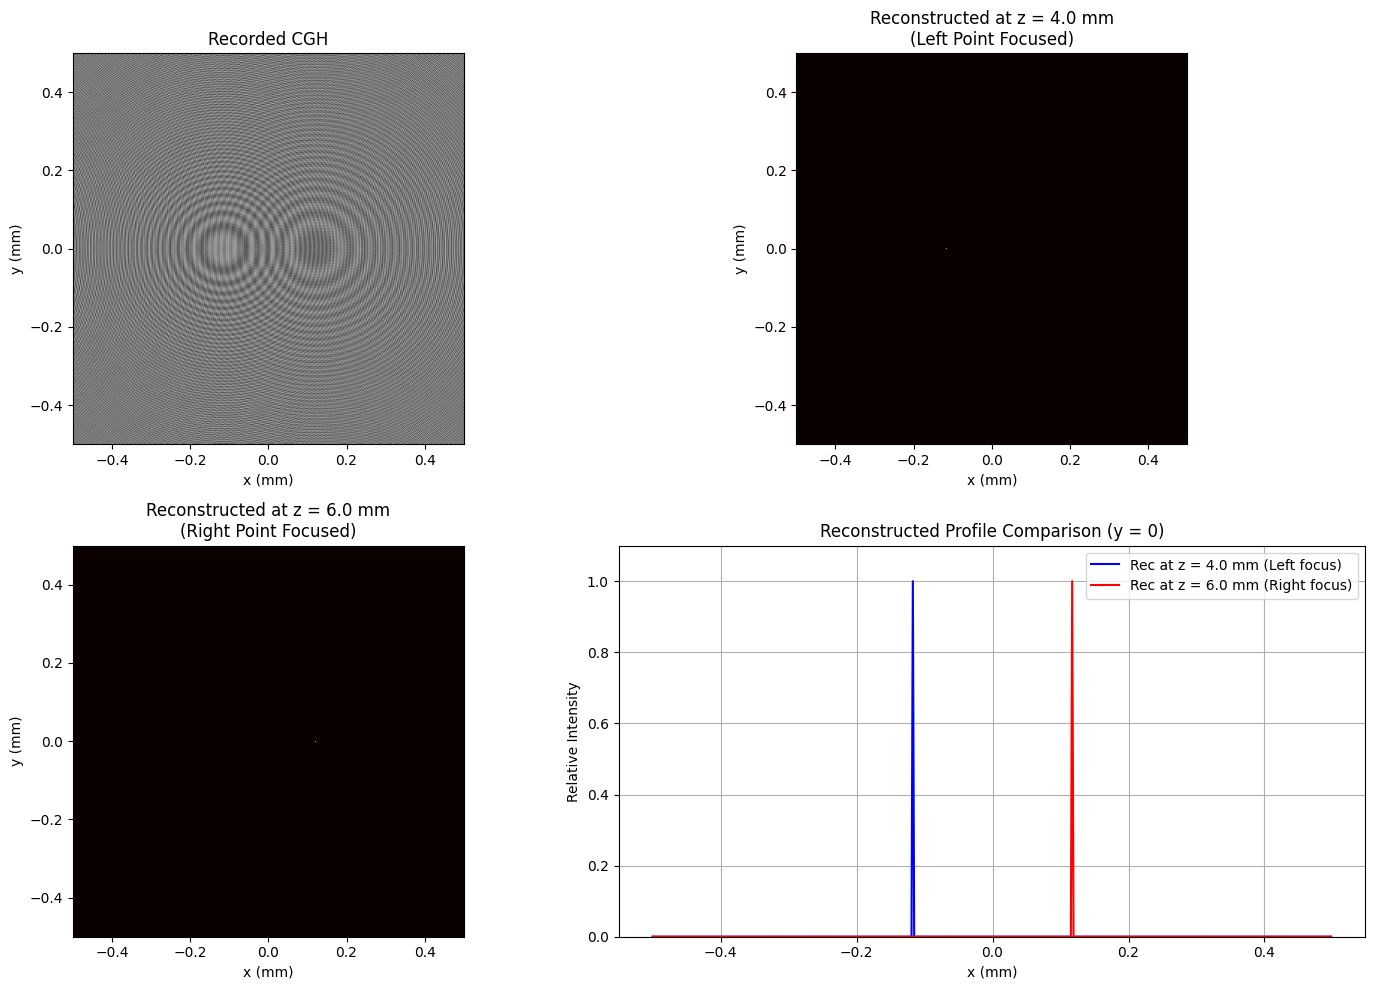

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. パラメータ設定 ---
N = 512                 # グリッドの分割数 (N x N)
L = 1.0e-3              # 計算領域のサイズ [m] (1.0 mm)
wavelength = 632.8e-9   # 光の波長 [m] (He-Neレーザー: 632.8 nm)

dx = L / N              # 画素ピッチ [m]
k = 2 * np.pi / wavelength  # 波数

# 座標系の構築 (実空間)
x = np.linspace(-L/2, L/2, N, endpoint=False)
y = np.linspace(-L/2, L/2, N, endpoint=False)
X, Y = np.meshgrid(x, y)

# 座標系の構築 (空間周波数空間)
fx = np.fft.fftfreq(N, d=dx)
fy = np.fft.fftfreq(N, d=dx)
FX, FY = np.meshgrid(fx, fy)

# --- 2. 角スペクトル法 (ASM) による伝搬関数の定義 ---
def propagate_asm(u_in, z_dist, wavelength, FX, FY):
    """角スペクトル法を用いて複素振幅 u_in を距離 z_dist だけ伝搬させる"""
    U_in = np.fft.fft2(u_in)
    term = (1/wavelength)**2 - FX**2 - FY**2
    term[term<0]=0
    H = np.exp(1j * 2 * np.pi * z_dist * np.sqrt(term))
    u_out = np.fft.ifft2(U_in * H)
    return u_out

# --- 3. 【記録フェーズ】 ---
u_object_plane1 = np.zeros((N, N), dtype=complex)
u_object_plane2 = np.zeros((N, N), dtype=complex)

# 2つの点光源を60画素離れた位置に配置
offset = 60
u_object_plane1[N//2, N//2 - offset] = 1.0  # 左側の点
u_object_plane2[N//2, N//2 + offset] = 1.0  # 右側の点

# 左右の点光源に対して、それぞれ異なる記録距離を設定
z1 = 4.0e-3  # 左側の点の記録距離 (4.0 mm)
z2 = 6.0e-3  # 右側の点の記録距離 (6.0 mm)

# それぞれの距離からホログラム面 (z=0) へ伝搬させて重ね合わせる
u_object_prop1 = propagate_asm(u_object_plane1, z1, wavelength, FX, FY)
u_object_prop2 = propagate_asm(u_object_plane2, z2, wavelength, FX, FY)
u_object_prop_total = u_object_prop1 + u_object_prop2

# 参照光（平行光、光軸に並行な平面波）
u_reference = np.ones((N, N), dtype=complex)

# ゾーンプレート
I_hologram_real = np.real(u_object_prop_total)

# --- 4. 【再生フェーズ】 ---
# ゾーンプレートに参照光を照射して再生する
u_reconstruction_plane = I_hologram_real * u_reference

# 異なる2つの奥行き z1, z2 それぞれにピントを合わせて逆伝搬再生する
# 1. z1 = 4.0 mm にピントを合わせる再生（距離 -z1）
u_reconstructed_z1 = propagate_asm(u_reconstruction_plane, -z1, wavelength, FX, FY)
intensity_rec_z1 = np.abs(u_reconstructed_z1)**2

# 2. z2 = 6.0 mm にピントを合わせる再生（距離 -z2）
u_reconstructed_z2 = propagate_asm(u_reconstruction_plane, -z2, wavelength, FX, FY)
intensity_rec_z2 = np.abs(u_reconstructed_z2)**2

# --- 5. 結果のプロット ---
plt.figure(figsize=(15, 10))

# 1. 記録されたホログラム（異なる2つの球面波が干渉し合って重なったパターン）
plt.subplot(2, 2, 1)
plt.imshow(I_hologram_real, extent=[-L*1e3/2, L*1e3/2, -L*1e3/2, L*1e3/2], cmap='gray')
plt.title("Recorded CGH")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")

# 2. z = 4.0 mm での再生像（左の点にピントが合い、右の点はボケる）
plt.subplot(2, 2, 2)
# 最大値で正規化
norm_z1 = intensity_rec_z1 / np.max(intensity_rec_z1)
plt.imshow(norm_z1, extent=[-L*1e3/2, L*1e3/2, -L*1e3/2, L*1e3/2], cmap='hot')
plt.title(f"Reconstructed at z = {z1*1e3:.1f} mm\n(Left Point Focused)")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")

# 3. z = 6.0 mm での再生像（右の点にピントが合い、左の点はボケる）
plt.subplot(2, 2, 3)
norm_z2 = intensity_rec_z2 / np.max(intensity_rec_z2)
plt.imshow(norm_z2, extent=[-L*1e3/2, L*1e3/2, -L*1e3/2, L*1e3/2], cmap='hot')
plt.title(f"Reconstructed at z = {z2*1e3:.1f} mm\n(Right Point Focused)")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")

# 4. それぞれのピント面でのx軸中央プロファイルの比較
plt.subplot(2, 2, 4)
plt.plot(x * 1e3, norm_z1[N//2, :], color='blue', label=f'Rec at z = {z1*1e3:.1f} mm (Left focus)')
plt.plot(x * 1e3, norm_z2[N//2, :], color='red', linestyle='-', label=f'Rec at z = {z2*1e3:.1f} mm (Right focus)')
plt.title("Reconstructed Profile Comparison (y = 0)")
plt.xlabel("x (mm)")
plt.ylabel("Relative Intensity")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()